# 🎵 Musikgenre-Klassifikation — V3
> KNN · SVM · Random Forest · Gradient Boosting · Optimiertes Ensemble

**Verbesserungen gegenüber V2:**
- ✅ Sauberer Train/Test-Split **vor** der Augmentation (kein Data Leakage)
- ✅ 6× Augmentation (Pitch +2, Pitch -2, Stretch ×1.1, Stretch ×0.9, Noise) → ~4800 Trainingssamples
- ✅ Optimiertes Ensemble (KNN raus, SVM stärker gewichtet)
- ✅ np.atleast_1d Fix für librosa.beat.beat_track Kompatibilität

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import librosa
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print('✅ Alle Imports erfolgreich')

✅ Alle Imports erfolgreich


## 2. Feature Extraction

Zwei Funktionen:
- `extract_features(file_path)` — lädt eine Datei und extrahiert Features
- `extract_features_from_array(y, sr)` — extrahiert Features direkt aus einem numpy Array (für Augmentation)

| Feature | Dimension | Beschreibung |
|---|---|---|
| MFCC | 20 × 2 | Klangfarbe / Timbre |
| Chroma | 12 × 2 | Tonhöhenverteilung |
| Spectral Centroid | 1 × 2 | 'Helligkeit' des Klangs |
| Spectral Bandwidth | 1 × 2 | Frequenzbreite |
| Spectral Rolloff | 1 × 2 | Hochfrequenzanteil |
| ZCR | 1 × 2 | Rauigkeit / Noisiness |
| RMS Energy | 1 × 2 | Lautstärke-Dynamik |
| Tempo | 1 | Geschätzte BPM |

In [2]:
def extract_features_from_array(y, sr):
    """
    Feature Extraction direkt aus einem numpy Array.
    Wird für die Augmentation verwendet.
    """
    features = []

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))

    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features.extend(np.mean(chroma, axis=1))
    features.extend(np.std(chroma, axis=1))

    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features.append(np.mean(centroid))
    features.append(np.std(centroid))

    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features.append(np.mean(bandwidth))
    features.append(np.std(bandwidth))

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features.append(np.mean(rolloff))
    features.append(np.std(rolloff))

    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    rms = librosa.feature.rms(y=y)
    features.append(np.mean(rms))
    features.append(np.std(rms))

    # np.atleast_1d Fix für librosa Versionskompatibilität
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features.append(float(np.atleast_1d(tempo)[0]))

    return np.array(features)


def extract_features(file_path):
    """
    Lädt eine Audiodatei und extrahiert Features.
    """
    y, sr = librosa.load(file_path, duration=30)
    return extract_features_from_array(y, sr)


print(f'Feature-Vektor hat {20*2 + 12*2 + 5*2 + 1} Dimensionen')
print('✅ Feature-Funktionen bereit')

Feature-Vektor hat 75 Dimensionen
✅ Feature-Funktionen bereit


## 3. Originaldaten laden & Split

**V3 Verbesserung gegenüber V2:**

Der Train/Test-Split passiert **vor** der Augmentation.
So können keine augmentierten Versionen eines Tracks im Test landen,
wenn das Original im Training ist — kein Data Leakage.

```
1000 Originals → Split → 800 Train | 200 Test
                              ↓
                         Augmentation (×5)
                              ↓
                    4800 Train | 200 Test ✅
```

In [3]:
DATASET_PATH = r"C:\DHBW\Data & KI\data\archive\Data\genres_original"

data_orig = []
labels_orig = []
errors = []

genres = sorted(os.listdir(DATASET_PATH))
print(f'Gefundene Genres ({len(genres)}): {genres}\n')

for genre in genres:
    genre_path = os.path.join(DATASET_PATH, genre)
    if not os.path.isdir(genre_path):
        continue

    files = [f for f in os.listdir(genre_path) if f.endswith('.wav')]
    print(f'  {genre}: {len(files)} Dateien ...', end=' ')

    ok = 0
    for file in files:
        file_path = os.path.join(genre_path, file)
        try:
            features = extract_features(file_path)
            data_orig.append(features)
            labels_orig.append(genre)
            ok += 1
        except Exception as e:
            errors.append((file_path, str(e)))

    print(f'{ok} OK')

X_orig = np.array(data_orig)
y_orig = np.array(labels_orig)

print(f'\n✅ Originaldaten geladen: {X_orig.shape[0]} Samples, {X_orig.shape[1]} Features')
if errors:
    print(f'⚠️  {len(errors)} Fehler beim Laden')

Gefundene Genres (10): ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

  blues: 100 Dateien ... 100 OK
  classical: 100 Dateien ... 100 OK
  country: 100 Dateien ... 100 OK
  disco: 100 Dateien ... 100 OK
  hiphop: 100 Dateien ... 100 OK
  jazz: 100 Dateien ... 99 OK
  metal: 100 Dateien ... 100 OK
  pop: 100 Dateien ... 100 OK
  reggae: 100 Dateien ... 100 OK
  rock: 100 Dateien ... 100 OK

✅ Originaldaten geladen: 999 Samples, 75 Features
⚠️  1 Fehler beim Laden


## 4. Train/Test-Split (vor Augmentation)

In [4]:
# Split auf Original-Tracks — Test bleibt sauber
X_train_orig, X_test, y_train_orig, y_test = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)

print(f'Original Train: {X_train_orig.shape[0]} Samples')
print(f'Test (sauber):  {X_test.shape[0]} Samples (wird NICHT augmentiert)')

Original Train: 799 Samples
Test (sauber):  200 Samples (wird NICHT augmentiert)


## 5. Data Augmentation (nur Trainingsdaten)

6 Varianten pro Track:

| # | Methode | Beschreibung |
|---|---|---|
| 1 | Original | unverändert |
| 2 | Pitch +2 | 2 Halbtöne höher |
| 3 | Pitch -2 | 2 Halbtöne tiefer |
| 4 | Stretch ×1.1 | 10 % schneller |
| 5 | Stretch ×0.9 | 10 % langsamer |
| 6 | Noise | leises Rauschen |

→ 800 × 6 = **4800 Trainingssamples**

In [5]:
# Augmentation nur auf Trainingsdaten anwenden
# Dafür brauchen wir die Rohdaten (y, sr) der Trainingsdateien

X_train_aug = list(X_train_orig)  # Originals zuerst
y_train_aug = list(y_train_orig)

aug_errors = []

genres_train = sorted(set(y_train_orig))
for genre in genres_train:
    genre_path = os.path.join(DATASET_PATH, genre)
    files = [f for f in os.listdir(genre_path) if f.endswith('.wav')]

    print(f'  Augmentiere {genre} ...', end=' ')
    ok = 0

    for file in files:
        file_path = os.path.join(genre_path, file)

        # Prüfen ob diese Datei im Trainingsset ist
        try:
            feat_orig = extract_features(file_path)
        except:
            continue

        # Nur augmentieren wenn Feature-Vektor im Trainingsset vorkommt
        is_train = any(np.allclose(feat_orig, x) for x in X_train_orig)
        if not is_train:
            continue

        try:
            y_audio, sr = librosa.load(file_path, duration=30)

            # Pitch +2
            y_p2 = librosa.effects.pitch_shift(y_audio, sr=sr, n_steps=2)
            X_train_aug.append(extract_features_from_array(y_p2, sr))
            y_train_aug.append(genre)

            # Pitch -2
            y_m2 = librosa.effects.pitch_shift(y_audio, sr=sr, n_steps=-2)
            X_train_aug.append(extract_features_from_array(y_m2, sr))
            y_train_aug.append(genre)

            # Time Stretch x1.1
            y_s1 = librosa.effects.time_stretch(y_audio, rate=1.1)
            X_train_aug.append(extract_features_from_array(y_s1, sr))
            y_train_aug.append(genre)

            # Time Stretch x0.9
            y_s2 = librosa.effects.time_stretch(y_audio, rate=0.9)
            X_train_aug.append(extract_features_from_array(y_s2, sr))
            y_train_aug.append(genre)

            # Noise
            y_n = y_audio + 0.005 * np.random.randn(len(y_audio))
            X_train_aug.append(extract_features_from_array(y_n, sr))
            y_train_aug.append(genre)

            ok += 1
        except Exception as e:
            aug_errors.append((file_path, str(e)))

    print(f'{ok} Tracks augmentiert')

X_train = np.array(X_train_aug)
y_train = np.array(y_train_aug)

print(f'\n✅ Augmentation abgeschlossen')
print(f'   Trainingssamples: {X_train.shape[0]} (vorher: {X_train_orig.shape[0]})')
print(f'   Testsamples:      {X_test.shape[0]} (unverändert, kein Leakage)')
if aug_errors:
    print(f'⚠️  {len(aug_errors)} Augmentation-Fehler')

  Augmentiere blues ... 80 Tracks augmentiert
  Augmentiere classical ... 80 Tracks augmentiert
  Augmentiere country ... 80 Tracks augmentiert
  Augmentiere disco ... 80 Tracks augmentiert
  Augmentiere hiphop ... 81 Tracks augmentiert
  Augmentiere jazz ... 79 Tracks augmentiert
  Augmentiere metal ... 83 Tracks augmentiert
  Augmentiere pop ... 81 Tracks augmentiert
  Augmentiere reggae ... 80 Tracks augmentiert
  Augmentiere rock ... 80 Tracks augmentiert

✅ Augmentation abgeschlossen
   Trainingssamples: 4819 (vorher: 799)
   Testsamples:      200 (unverändert, kein Leakage)


## 6. Preprocessing

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape[0]} Samples, {X_train_scaled.shape[1]} Features')
print(f'Test:  {X_test_scaled.shape[0]} Samples')
print(f'Genres: {sorted(set(y_train))}')

Train: 4819 Samples, 75 Features
Test:  200 Samples
Genres: [np.str_('blues'), np.str_('classical'), np.str_('country'), np.str_('disco'), np.str_('hiphop'), np.str_('jazz'), np.str_('metal'), np.str_('pop'), np.str_('reggae'), np.str_('rock')]


## 7. Modelle trainieren

### 7a. KNN

In [7]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'KNN Accuracy: {acc_knn:.4f} ({acc_knn*100:.1f} %)')

KNN Accuracy: 0.6550 (65.5 %)


### 7b. SVM mit Hyperparameter-Tuning

In [8]:
param_grid = {
    'C':     [1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01]
}

grid_search = GridSearchCV(
    SVC(kernel='rbf', probability=True),
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

svm = grid_search.best_estimator_
y_pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f'\nBeste Parameter: {grid_search.best_params_}')
print(f'SVM Accuracy:    {acc_svm:.4f} ({acc_svm*100:.1f} %)')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Beste Parameter: {'C': 10, 'gamma': 'auto'}
SVM Accuracy:    0.7400 (74.0 %)


### 7c. Random Forest

In [9]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {acc_rf:.4f} ({acc_rf*100:.1f} %)')

Random Forest Accuracy: 0.6850 (68.5 %)


### 7d. Gradient Boosting

In [10]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb.fit(X_train_scaled, y_train)

y_pred_gb = gb.predict(X_test_scaled)
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f'Gradient Boosting Accuracy: {acc_gb:.4f} ({acc_gb*100:.1f} %)')

Gradient Boosting Accuracy: 0.7150 (71.5 %)


### 7e. Optimiertes Ensemble

**V3 Verbesserung:** KNN wird entfernt da er deutlich schwächer ist.
SVM wird stärker gewichtet (×3) da es konsistent das beste Einzelmodell ist.

In [11]:
ensemble = VotingClassifier(
    estimators=[
        ('svm', SVC(kernel='rbf', probability=True,
                    C=grid_search.best_params_['C'],
                    gamma=grid_search.best_params_['gamma'])),
        ('rf',  RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
        ('gb',  GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                           max_depth=5, random_state=42))
    ],
    voting='soft',
    weights=[3, 2, 1],  # SVM stärker gewichtet
    n_jobs=-1
)
ensemble.fit(X_train_scaled, y_train)

y_pred_ens = ensemble.predict(X_test_scaled)
acc_ens = accuracy_score(y_test, y_pred_ens)
print(f'Ensemble Accuracy: {acc_ens:.4f} ({acc_ens*100:.1f} %)')

Ensemble Accuracy: 0.7350 (73.5 %)


## 8. Modellvergleich & Evaluation

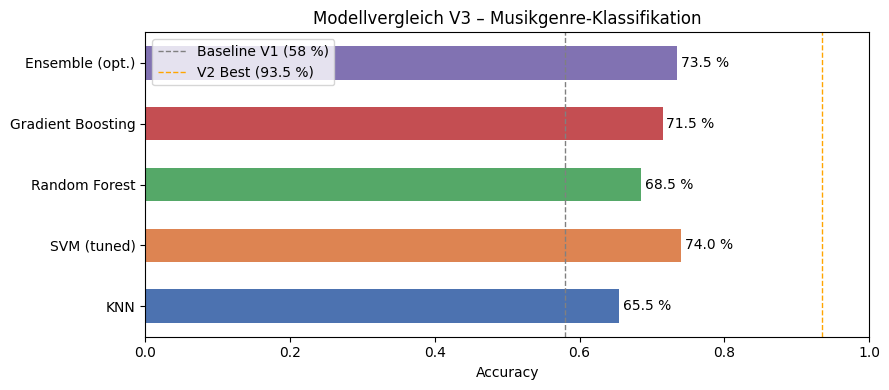


🏆 Bestes Modell: SVM (tuned) mit 74.0 %


In [12]:
results = {
    'KNN':               acc_knn,
    'SVM (tuned)':       acc_svm,
    'Random Forest':     acc_rf,
    'Gradient Boosting': acc_gb,
    'Ensemble (opt.)':   acc_ens,
}

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
bars = ax.barh(list(results.keys()), list(results.values()), color=colors, height=0.55)

ax.set_xlim(0, 1)
ax.axvline(0.58, color='gray', linestyle='--', linewidth=1, label='Baseline V1 (58 %)')
ax.axvline(0.935, color='orange', linestyle='--', linewidth=1, label='V2 Best (93.5 %)')
ax.set_xlabel('Accuracy')
ax.set_title('Modellvergleich V3 – Musikgenre-Klassifikation')
ax.legend()

for bar, val in zip(bars, results.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f} %', va='center', fontsize=10)

plt.tight_layout()
plt.show()

best_name = max(results, key=results.get)
print(f'\n🏆 Bestes Modell: {best_name} mit {results[best_name]*100:.1f} %')

### Confusion Matrices

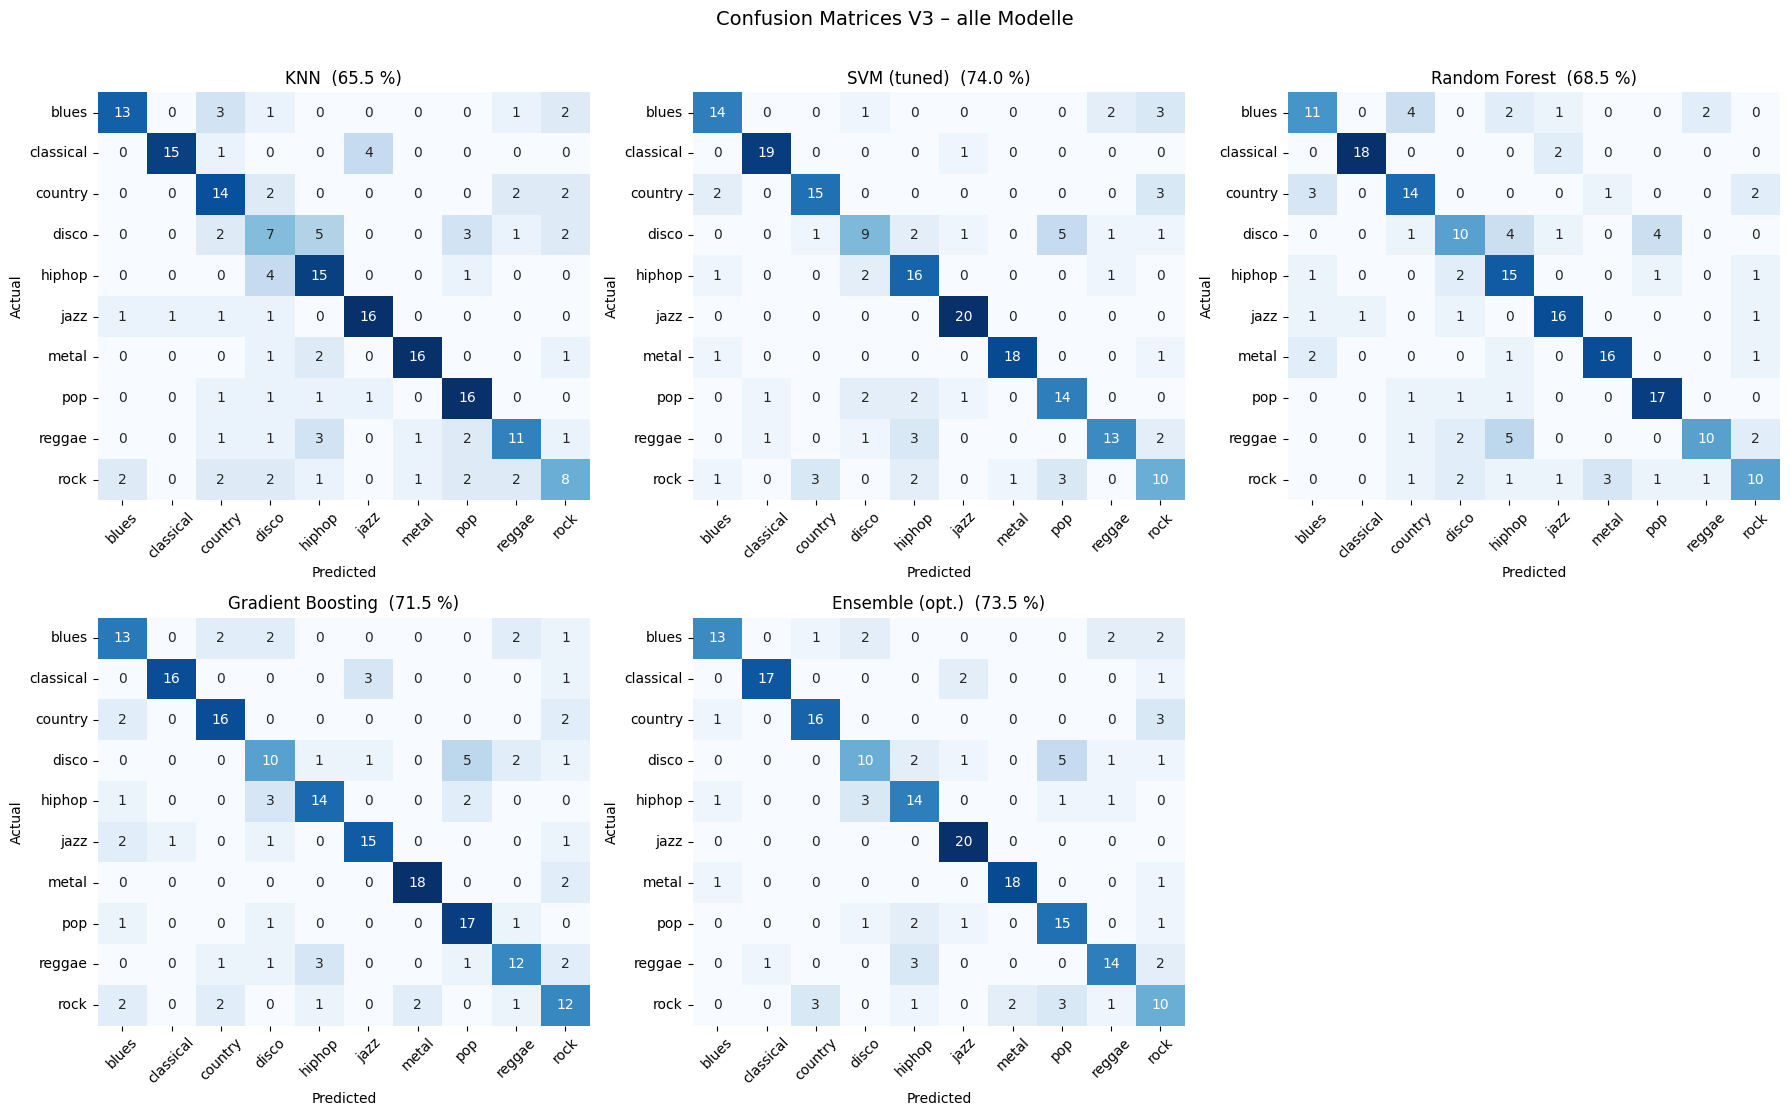

In [ ]:
all_preds = {
    'KNN':               y_pred_knn,
    'SVM (tuned)':       y_pred_svm,
    'Random Forest':     y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'Ensemble (opt.)':   y_pred_ens,
}

genre_labels = sorted(list(set(y_orig)))
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (name, preds) in enumerate(all_preds.items()):
    cm = confusion_matrix(y_test, preds, labels=genre_labels)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                xticklabels=genre_labels, yticklabels=genre_labels,
                cmap='Blues', cbar=False)
    axes[i].set_title(f'{name}  ({accuracy_score(y_test, preds)*100:.1f} %)')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices V3 - alle Modelle', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Detaillierte Classification Reports

In [14]:
for name, preds in all_preds.items():
    print(f'\n' + '='*55)
    print(f'  {name}  —  Accuracy: {accuracy_score(y_test, preds)*100:.1f} %')
    print('='*55)
    print(classification_report(y_test, preds, target_names=genre_labels))


  KNN  —  Accuracy: 65.5 %
              precision    recall  f1-score   support

       blues       0.81      0.65      0.72        20
   classical       0.94      0.75      0.83        20
     country       0.56      0.70      0.62        20
       disco       0.35      0.35      0.35        20
      hiphop       0.56      0.75      0.64        20
        jazz       0.76      0.80      0.78        20
       metal       0.89      0.80      0.84        20
         pop       0.67      0.80      0.73        20
      reggae       0.65      0.55      0.59        20
        rock       0.50      0.40      0.44        20

    accuracy                           0.66       200
   macro avg       0.67      0.66      0.66       200
weighted avg       0.67      0.66      0.66       200


  SVM (tuned)  —  Accuracy: 74.0 %
              precision    recall  f1-score   support

       blues       0.74      0.70      0.72        20
   classical       0.90      0.95      0.93        20
     country  

### Feature Importance (Random Forest)

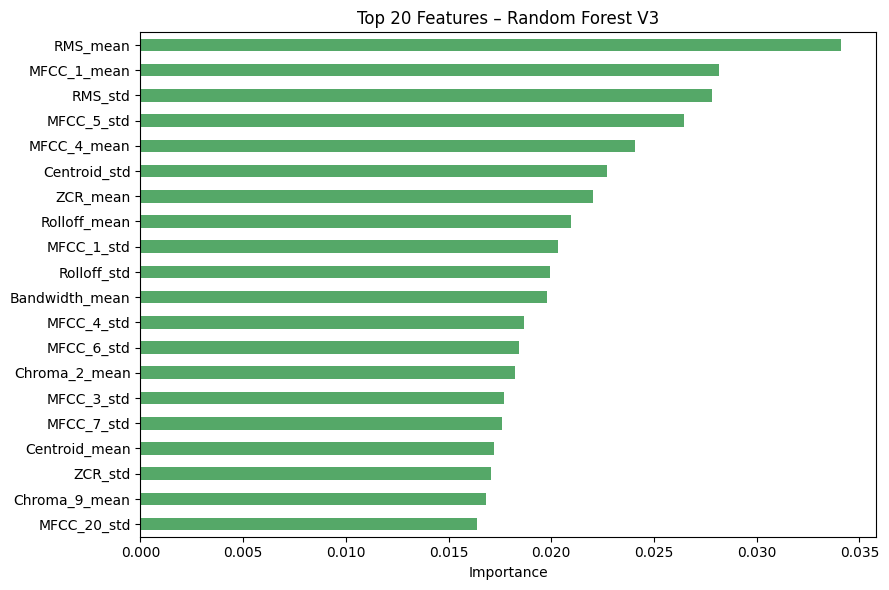

In [ ]:
feat_names = []
for i in range(20): feat_names.append(f'MFCC_{i+1}_mean')
for i in range(20): feat_names.append(f'MFCC_{i+1}_std')
for i in range(12): feat_names.append(f'Chroma_{i+1}_mean')
for i in range(12): feat_names.append(f'Chroma_{i+1}_std')
for feat in ['Centroid', 'Bandwidth', 'Rolloff', 'ZCR', 'RMS']:
    feat_names.append(f'{feat}_mean')
    feat_names.append(f'{feat}_std')
feat_names.append('Tempo')

importances = pd.Series(rf.feature_importances_, index=feat_names)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot.barh(ax=ax, color='#55A868')
ax.set_title('Top 20 Features - Random Forest V3')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 9. Cross-Validation

5-Fold CV auf dem kompletten augmentierten Datensatz.

In [16]:
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])
X_all_scaled = scaler.transform(X_all)

cv_models = {
    'KNN':               KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    'SVM (tuned)':       SVC(kernel='rbf', probability=True,
                             C=grid_search.best_params_['C'],
                             gamma=grid_search.best_params_['gamma']),
    'Random Forest':     RandomForestClassifier(n_estimators=300, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
}

print('5-Fold Cross-Validation:')
print(f'{"Modell":<25} {"Mean":>8}  {"Std":>7}')
print('-' * 42)

for name, model in cv_models.items():
    scores = cross_val_score(model, X_all_scaled, y_all, cv=5, n_jobs=-1)
    print(f'{name:<25} {scores.mean():.4f}   ± {scores.std():.4f}')

5-Fold Cross-Validation:
Modell                        Mean      Std
------------------------------------------
KNN                       0.6884   ± 0.0909
SVM (tuned)               0.8675   ± 0.0312
Random Forest             0.8181   ± 0.0573
Gradient Boosting         0.7854   ± 0.0642
